In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

Saving whatsapp_classification_dataset_10000.csv to whatsapp_classification_dataset_10000.csv


In [2]:
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

df.head()

,name,number,isadmin,timestamp,group_name,message_data,word_count,has_placement,has_exam,has_deadline,has_event,category,sentiment_score,urgency_score
0,Priya,1,1,2026-05-19 09:00:00,AI Club,No classes on Friday due to maintenance,7,0,0,0,0,holiday_notice,0.18,9.8
1,Divya,2,1,2026-05-19 09:07:00,CSE Internal Tests,Mock interview scheduled for today evening,6,1,0,0,0,placement_test,0.13,6.7
2,Priya,3,1,2026-05-19 09:14:00,Final Year Projects,No classes on Friday due to maintenance,7,0,0,0,0,holiday_notice,0.84,7.9
3,Rohit,4,1,2026-05-19 09:21:00,CSE Assignments,CN internal exam on Wednesday,5,0,1,0,0,exam_notification,0.15,5.9
4,Rahul,5,0,2026-05-19 09:28:00,CSE Placement Updates,Wipro interview shortlist released,4,1,0,0,0,placement_test,0.47,5.0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 10000
Columns: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             10000 non-null  object 
 1   number           10000 non-null  int64  
 2   isadmin          10000 non-null  int64  
 3   timestamp        10000 non-null  object 
 4   group_name       10000 non-null  object 
 5   message_data     10000 non-null  object 
 6   word_count       10000 non-null  int64  
 7   has_placement    10000 non-null  int64  
 8   has_exam         10000 non-null  int64  
 9   has_deadline     10000 non-null  int64  
 10  has_event        10000 non-null  int64  
 11  category         10000 non-null  object 
 12  sentiment_score  10000 non-null  float64
 13  urgency_score    10000 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 1.1+ MB


In [4]:
print(df.isnull().sum())

name               0
number             0
isadmin            0
timestamp          0
group_name         0
message_data       0
word_count         0
has_placement      0
has_exam           0
has_deadline       0
has_event          0
category           0
sentiment_score    0
urgency_score      0
dtype: int64


In [5]:
X = df["message_data"]
y = df["category"]

print(y.value_counts())

category
placement_test         2519
exam_notification      2508
assignment_notice      2446
admin_notice           2378
assignment_deadline      56
event                    56
holiday_notice           37
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 8000
Testing Data: 2000


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

Training Shape: (8000, 7880)
Testing Shape: (2000, 7880)


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='linear'),
    "Naive Bayes": MultinomialNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [10]:
results = []

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, accuracy])

    print(f"{name} Accuracy = {accuracy:.4f}")

Logistic Regression Accuracy = 1.0000
Decision Tree Accuracy = 1.0000
Random Forest Accuracy = 1.0000
SVM Accuracy = 1.0000
Naive Bayes Accuracy = 0.9905
KNN Accuracy = 1.0000


In [11]:
comparison_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy"]
)

comparison_df

,Model,Accuracy
0,Logistic Regression,1.0000
1,Decision Tree,1.0000
2,Random Forest,1.0000
3,SVM,1.0000
4,Naive Bayes,0.9905
5,KNN,1.0000


In [12]:
comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df.reset_index(drop=True, inplace=True)

comparison_df

,Model,Accuracy
0,Logistic Regression,1.0000
1,Decision Tree,1.0000
2,Random Forest,1.0000
3,SVM,1.0000
4,KNN,1.0000
5,Naive Bayes,0.9905


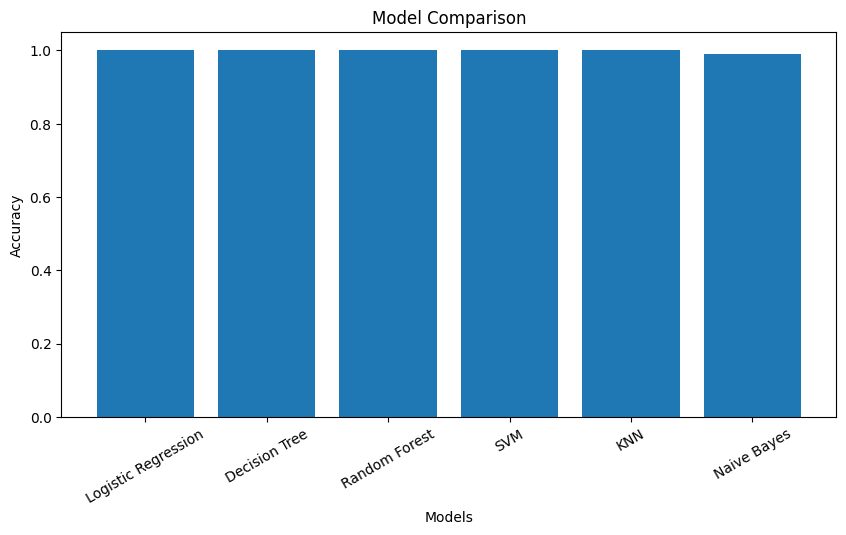

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()

In [14]:
best_model = comparison_df.iloc[0]

print("Best Model")
print("Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])

Best Model
Model : Logistic Regression
Accuracy : 1.0


In [15]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Selected Model:", best_model_name)

Selected Model: Logistic Regression
